# 01 — Tanager load and preprocess

Loads a Tanager scene, previews it as true-color and false-color composites, and selects a vegetated region of interest (ROI) with cloud/nodata/shadow masking.

**Input:** a Tanager scene downloaded per `data/README.md` (HDF5, `basic_sr_hdf5`). This notebook uses Planet's own atmospherically-corrected `surface_reflectance` product directly — see `src/atmospheric.py` for why this repo does not re-derive reflectance from radiance as a required step.

**Scene used:** `20250918_112737_91_4001` — Rezonville, Metz, Grand Est, France (agriculture collection, 0% cloud cover). See `data/README.md` for why this scene was chosen (no Ukraine scene exists in the open catalog).

Uses PROSPECT-D/4SAIL-relevant spectral ranges downstream (see `REFERENCES.md`); this notebook only handles I/O and preprocessing.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent))
from src import tanager_io, atmospheric, channel_selector

Matplotlib is building the font cache; this may take a moment.


## Scene path

Point this at your locally downloaded scene (see `data/README.md`). Not committed to the repository.

In [2]:
SCENE_SR_PATH = Path("../data/tanager_scene_01/scene_basic_sr.h5")

## Load surface reflectance scene

In [3]:
if not SCENE_SR_PATH.exists():
    raise FileNotFoundError(
        f"No scene found at {SCENE_SR_PATH}. Download a Tanager basic_sr_hdf5 "
        "scene per data/README.md and update SCENE_SR_PATH above."
    )

scene = tanager_io.load_surface_reflectance(SCENE_SR_PATH)
wavelengths = scene.wavelengths
reflectance = scene.cube

print(f"Reflectance cube shape: {reflectance.shape}")
print(f"Bands: {len(wavelengths)}, range {wavelengths.min():.0f}-{wavelengths.max():.0f} nm")
print(f"Cloudy pixels: {scene.cloud_mask.sum()} / {scene.cloud_mask.size} "
      f"({100 * scene.cloud_mask.mean():.2f}%)")
print(f"No-data pixels: {scene.nodata_mask.sum()}")

Reflectance cube shape: (736, 607, 426)
Bands: 426, range 376-2499 nm
Cloudy pixels: 215 / 446752 (0.05%)
No-data pixels: 0


## Mask cloudy / no-data pixels

`surface_reflectance` is Planet's official atmospherically-corrected product (see `src/atmospheric.py` docstring for why this repo doesn't re-derive it). Invalidate cloudy and no-data pixels here so they don't leak into the ROI/vegetation mask below.

In [4]:
invalid_pixels = scene.cloud_mask | scene.cirrus_mask | scene.nodata_mask
reflectance = reflectance.copy()
reflectance[invalid_pixels] = np.nan

print(f"Invalidated pixels: {invalid_pixels.sum()} / {invalid_pixels.size} "
      f"({100 * invalid_pixels.mean():.2f}%)")

Invalidated pixels: 215 / 446752 (0.05%)


## RGB and false-color preview

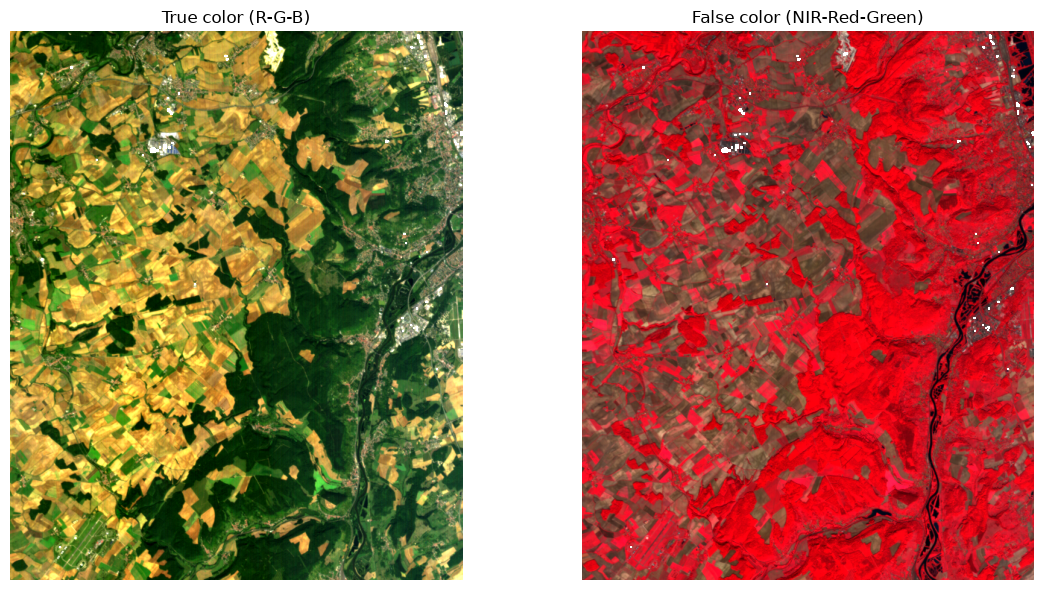

In [5]:
rgb_bands = channel_selector.nearest_band_indices(
    wavelengths, {"red": 650, "green": 560, "blue": 450}
)
false_color_bands = channel_selector.nearest_band_indices(
    wavelengths, {"nir": 840, "red": 650, "green": 560}
)


def stretch(cube_slice, p_low=2, p_high=98):
    lo, hi = np.nanpercentile(cube_slice, [p_low, p_high])
    return np.clip((cube_slice - lo) / (hi - lo), 0, 1)


rgb = np.stack(
    [reflectance[:, :, rgb_bands[c]] for c in ("red", "green", "blue")], axis=-1
)
false_color = np.stack(
    [reflectance[:, :, false_color_bands[c]] for c in ("nir", "red", "green")], axis=-1
)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(stretch(rgb))
axes[0].set_title("True color (R-G-B)")
axes[0].axis("off")
axes[1].imshow(stretch(false_color))
axes[1].set_title("False color (NIR-Red-Green)")
axes[1].axis("off")
plt.tight_layout()
plt.savefig("../results/figures/01_scene_preview.png", dpi=150)
plt.show()

## Vegetated ROI selection

NDVI thresholding on top of the cloud/nodata mask already applied above (no separate shadow heuristic needed — Planet's `beta_cloud_mask`/`beta_cirrus_mask`/`nodata_pixels` cover it).

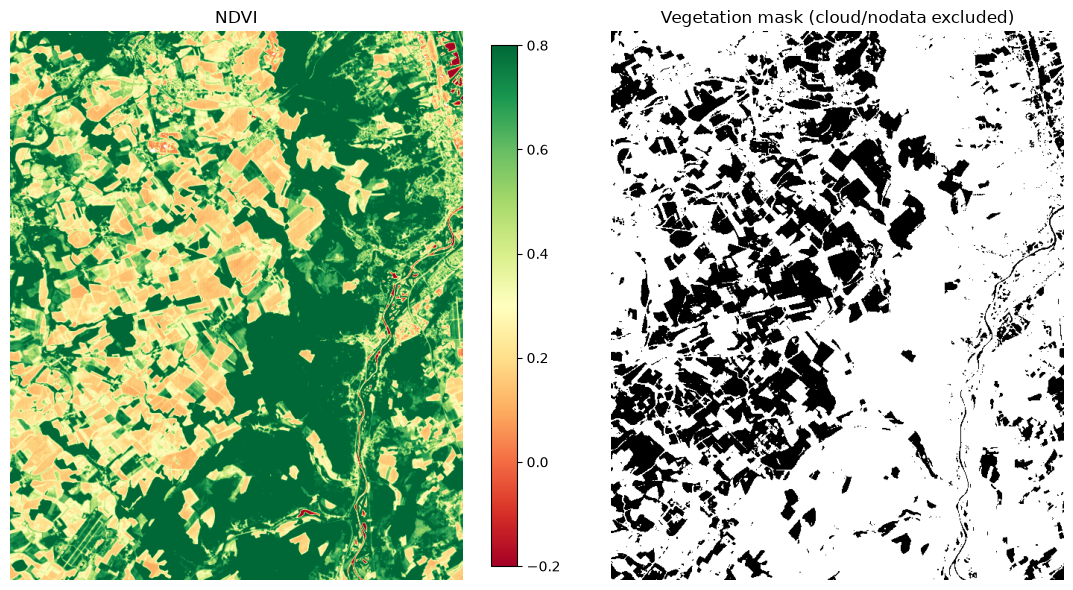

Vegetated pixels: 327418 / 446752 (73.3%)


In [6]:
nir = reflectance[:, :, false_color_bands["nir"]]
red = reflectance[:, :, rgb_bands["red"]]
ndvi = (nir - red) / (nir + red + 1e-6)

NDVI_VEG_THRESHOLD = 0.3  # TODO: tune per scene

vegetation_mask = (ndvi > NDVI_VEG_THRESHOLD) & ~invalid_pixels

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
im = axes[0].imshow(ndvi, cmap="RdYlGn", vmin=-0.2, vmax=0.8)
axes[0].set_title("NDVI")
axes[0].axis("off")
plt.colorbar(im, ax=axes[0], fraction=0.046)
axes[1].imshow(vegetation_mask, cmap="gray")
axes[1].set_title("Vegetation mask (cloud/nodata excluded)")
axes[1].axis("off")
plt.tight_layout()
plt.savefig("../results/figures/01_roi_mask.png", dpi=150)
plt.show()

print(f"Vegetated pixels: {vegetation_mask.sum()} / {vegetation_mask.size} "
      f"({100 * vegetation_mask.mean():.1f}%)")

## Next steps

`reflectance`, `wavelengths`, and `vegetation_mask` from this notebook feed directly into `02_prospect_d_forward_model.ipynb`.